#**BRAIN TUMOR CLASSIFICATION**

###**Downloading dataset**

In [1]:
from google.colab import files
files.upload()


Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{\n  "username": "Tarekelaminee",\n  "key": "KGAT_13d48a741652c5b825c6780fb43ae24f"\n}\n'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:04<00:00, 35.3MB/s]



In [5]:
!unzip brain-tumor-mri-dataset.zip -d brain_tumor_data

Streaming output truncated to the last 5000 lines.
  inflating: brain_tumor_data/Training/glioma/Tr-gl_279.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_28.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_280.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_281.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_282.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_283.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_284.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_285.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_286.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_287.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_288.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_289.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_29.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_290.jpg  
  inflating: brain_tumor_data/Training/glioma/Tr-gl_291.jpg  
  inflating: brain_tu

###**Exploratory Data Analysis**

In [6]:
import os

for root, dirs, files in os.walk("brain_tumor_data"):
    print(root, "->", len(files), "files")


brain_tumor_data -> 0 files
brain_tumor_data/Training -> 0 files
brain_tumor_data/Training/pituitary -> 1400 files
brain_tumor_data/Training/meningioma -> 1400 files
brain_tumor_data/Training/glioma -> 1400 files
brain_tumor_data/Training/notumor -> 1400 files
brain_tumor_data/Testing -> 0 files
brain_tumor_data/Testing/pituitary -> 400 files
brain_tumor_data/Testing/meningioma -> 400 files
brain_tumor_data/Testing/glioma -> 400 files
brain_tumor_data/Testing/notumor -> 400 files


In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import pandas as pd

In [8]:
base_path = "brain_tumor_data"
train_path = os.path.join(base_path, "Training")
test_path = os.path.join(base_path, "Testing")

classes = ["glioma", "meningioma", "pituitary", "notumor"]


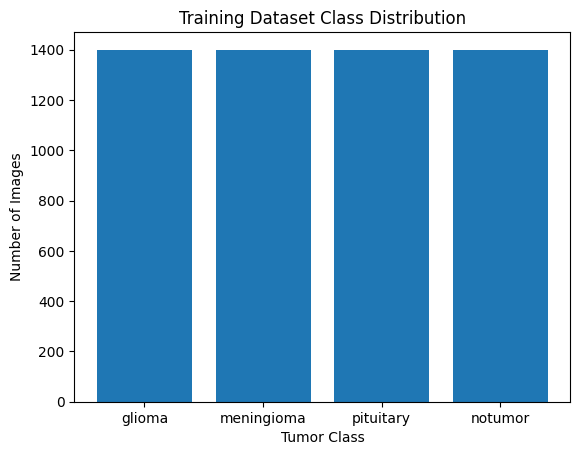

In [9]:
train_counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in classes]

plt.figure()
plt.bar(classes, train_counts)
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.show()


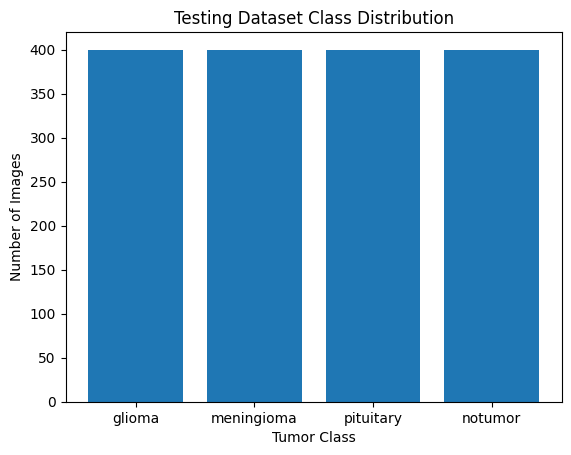

In [10]:
test_counts = [len(os.listdir(os.path.join(test_path, cls))) for cls in classes]

plt.figure()
plt.bar(classes, test_counts)
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.title("Testing Dataset Class Distribution")
plt.show()


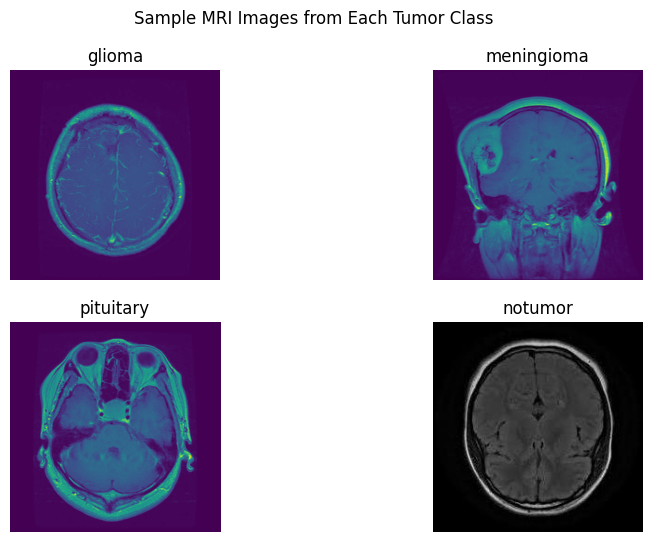

In [11]:
plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_path, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample MRI Images from Each Tumor Class")
plt.show()


In [12]:
base_path = "brain_tumor_data/Training"
classes = ["glioma", "meningioma", "pituitary", "notumor"]

image_paths = []

for cls in classes:
    cls_path = os.path.join(base_path, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))

df = pd.DataFrame(image_paths, columns=["full_path"])

print("Total images:", len(df))
df.head()


Total images: 5600


,full_path
0,brain_tumor_data/Training/glioma/Tr-gl_664.jpg
1,brain_tumor_data/Training/glioma/Tr-gl_913.jpg
2,brain_tumor_data/Training/glioma/Tr-gl_543.jpg
3,brain_tumor_data/Training/glioma/Tr-gl_821.jpg
4,brain_tumor_data/Training/glioma/Tr-gl_735.jpg


In [13]:
image_sizes = []

for file_path in df['full_path']:
    with Image.open(file_path) as img:
        image_sizes.append(img.size)

sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])
sizes_df.head()


,Width,Height
0,512,512
1,512,512
2,512,512
3,512,512
4,512,512


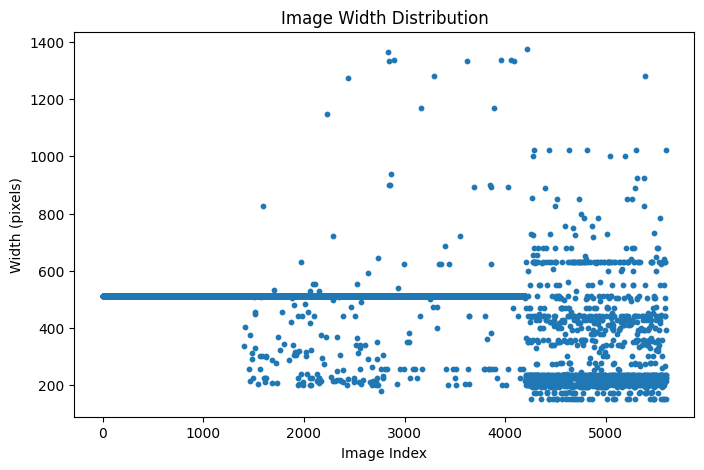

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(
    x=range(len(sizes_df)),
    y=sizes_df['Width'],
    s=10
)
plt.title('Image Width Distribution')
plt.xlabel('Image Index')
plt.ylabel('Width (pixels)')
plt.show()


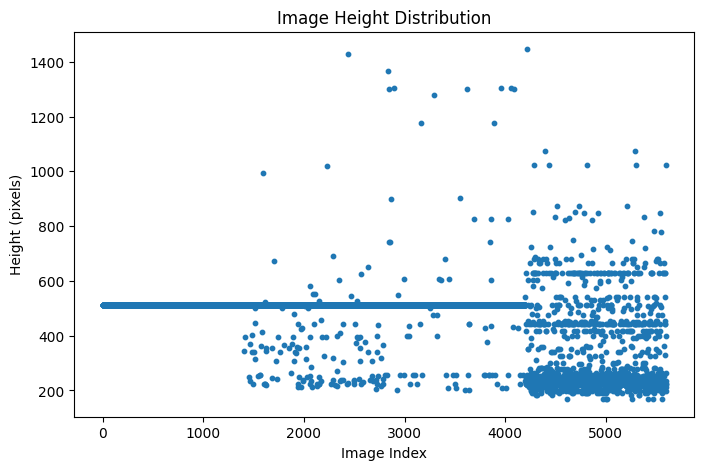

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(
    x=range(len(sizes_df)),
    y=sizes_df['Height'],
    s=10
)
plt.title('Image Height Distribution')
plt.xlabel('Image Index')
plt.ylabel('Height (pixels)')
plt.show()


In [16]:
unique_sizes = sizes_df.value_counts().reset_index(name='Count')
unique_sizes.head(10)


,Width,Height,Count
0,512,512,4012
1,225,225,253
2,630,630,69
3,201,251,40
4,236,236,39
5,442,442,38
6,150,198,33
7,232,217,32
8,228,221,32
9,428,417,31


In [17]:
image_data = []

for file_path in df['full_path']:
    with Image.open(file_path) as img:
        width, height = img.size
        mode = img.mode
        channels = len(img.getbands())
        image_data.append((width, height, mode, channels))

image_df = pd.DataFrame(
    image_data,
    columns=['Width', 'Height', 'Mode', 'Channels']
)

print("Image Mode Distribution:")
print(image_df['Mode'].value_counts())

print("\nNumber of Channels Distribution:")
print(image_df['Channels'].value_counts())


Image Mode Distribution:
Mode
RGB     3238
L       2358
RGBA       3
P          1
Name: count, dtype: int64

Number of Channels Distribution:
Channels
3    3238
1    2359
4       3
Name: count, dtype: int64


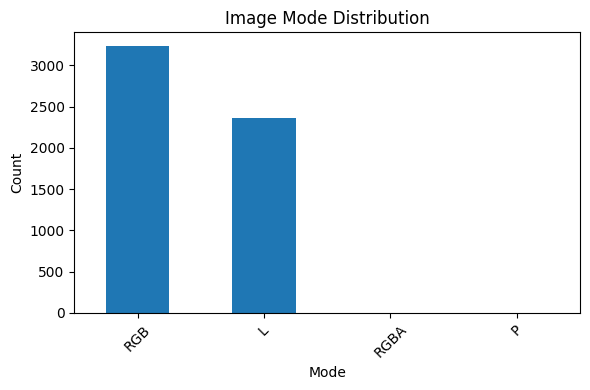

In [18]:
plt.figure(figsize=(6,4))
image_df['Mode'].value_counts().plot(kind='bar')
plt.title("Image Mode Distribution")
plt.xlabel("Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


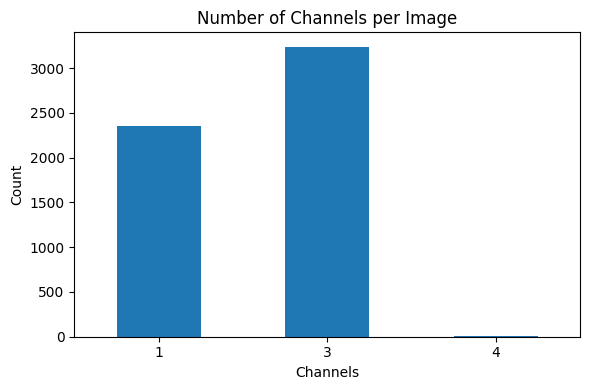

In [19]:
plt.figure(figsize=(6,4))
image_df['Channels'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Channels per Image")
plt.xlabel("Channels")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


###**Balanced Dataset using Pytorch Augmentation**

In [20]:
# === Balance Brain Tumor Dataset using PyTorch (ONE CELL) ===

import os, shutil, uuid, random
from tqdm import tqdm
from PIL import Image
import pandas as pd

import torch
from torchvision import transforms

# ---------------- CONFIG ----------------
train_dir = "brain_tumor_data/Training"
balanced_dir = "/content/brain_tumor_data_balanced"
classes = ["glioma", "meningioma", "pituitary", "notumor"]
target_count = 2000
img_size = 224
random.seed(42)

# ---------------- BUILD DATAFRAME ----------------
rows = []
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        rows.append((os.path.join(cls_path, img_name), cls))

df = pd.DataFrame(rows, columns=["full_path", "class"])
print("Original class distribution:\n", df["class"].value_counts(), "\n")

# ---------------- OUTPUT DIR ----------------
if os.path.exists(balanced_dir):
    shutil.rmtree(balanced_dir)
os.makedirs(balanced_dir, exist_ok=True)

# ---------------- PYTORCH AUGMENTATION ----------------
augment_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        shear=10,
        scale=(0.9, 1.1)
    )
])

# ---------------- BALANCING LOGIC ----------------
for cls in tqdm(classes, desc="Balancing classes"):
    class_df = df[df["class"] == cls]
    class_paths = class_df["full_path"].tolist()

    out_cls_dir = os.path.join(balanced_dir, cls)
    os.makedirs(out_cls_dir, exist_ok=True)

    # If more than target → downsample
    if len(class_paths) > target_count:
        class_paths = random.sample(class_paths, target_count)

    # Copy original images
    for p in class_paths:
        shutil.copy(p, out_cls_dir)

    current_count = len(class_paths)
    if current_count >= target_count:
        continue

    # Augment until target reached
    to_generate = target_count - current_count
    gen_count = 0

    while gen_count < to_generate:
        for img_path in class_paths:
            if gen_count >= to_generate:
                break

            img = Image.open(img_path).convert("RGB")
            aug_img = augment_transform(img)

            new_name = f"aug_{uuid.uuid4().hex}.jpg"
            aug_img.save(os.path.join(out_cls_dir, new_name))

            gen_count += 1

# ---------------- VERIFY ----------------
print("\nBalanced dataset distribution:")
for cls in classes:
    count = len(os.listdir(os.path.join(balanced_dir, cls)))
    print(f"{cls:12s}: {count}")

print("\nBalanced dataset saved at:", balanced_dir)


Original class distribution:
 class
glioma        1400
meningioma    1400
pituitary     1400
notumor       1400
Name: count, dtype: int64 



Balancing classes: 100%|██████████| 4/4 [00:10<00:00,  2.72s/it]


Balanced dataset distribution:
glioma      : 2000
meningioma  : 2000
pituitary   : 2000
notumor     : 2000

Balanced dataset saved at: /content/brain_tumor_data_balanced


###**Visualize Dataset Balance Again**

In [21]:
base_path = "/content/brain_tumor_data_balanced"
train_path = base_path


classes = ["glioma", "meningioma", "pituitary", "notumor"]


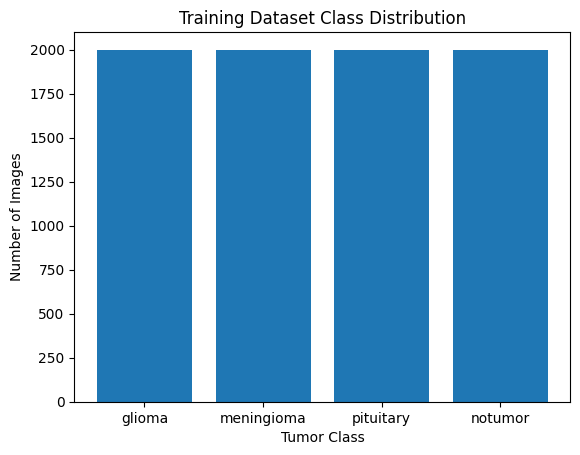

In [22]:
train_counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in classes]

plt.figure()
plt.bar(classes, train_counts)
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.show()


Using dataset at: /content/brain_tumor_data/Training


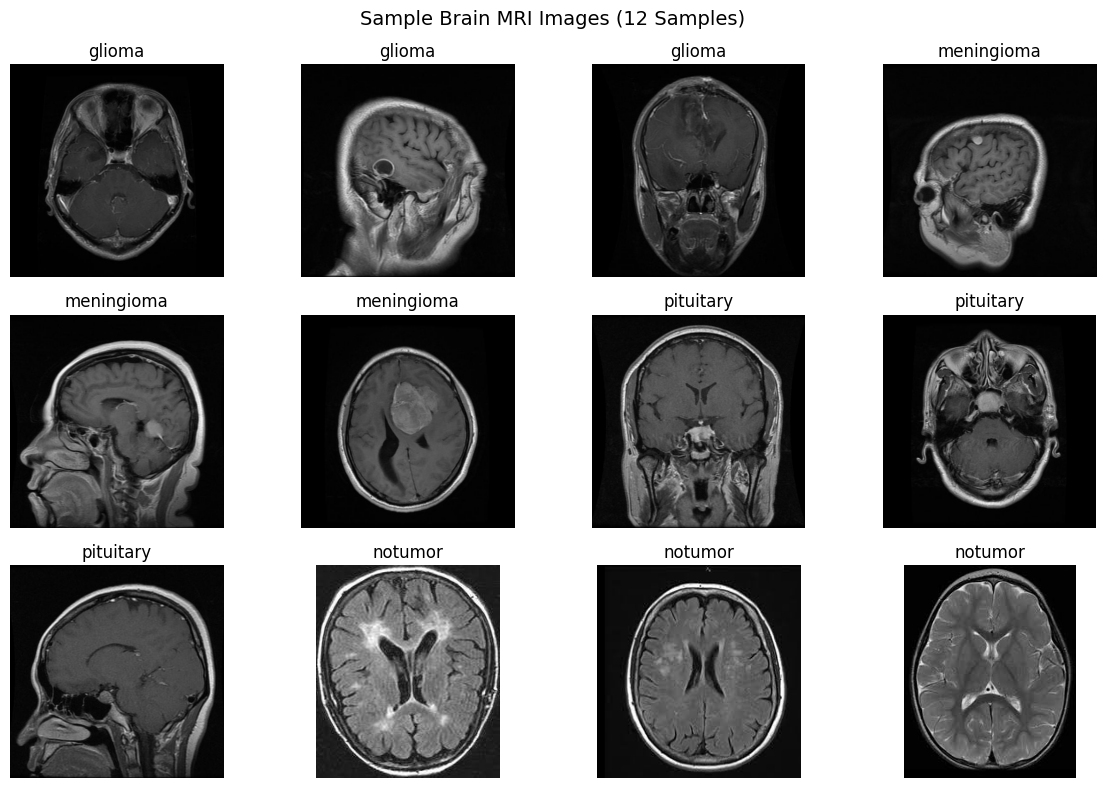

In [23]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# --------- AUTO-DETECT DATASET ROOT ---------
dataset_root = "/content/brain_tumor_data_balanced"

for root, dirs, files in os.walk("/content"):
    if "Training" in dirs:
        dataset_root = os.path.join(root, "Training")
        break

if dataset_root is None:
    raise FileNotFoundError("Training dataset folder not found. Please re-check extraction.")

print("Using dataset at:", dataset_root)

# Known classes
classes = ["glioma", "meningioma", "pituitary", "notumor"]

# --------- COLLECT 12 IMAGES (3 PER CLASS) ---------
image_paths = []
labels = []

for cls in classes:
    cls_path = os.path.join(dataset_root, cls)
    images = os.listdir(cls_path)
    samples = random.sample(images, 3)
    for img_name in samples:
        image_paths.append(os.path.join(cls_path, img_name))
        labels.append(cls)

# --------- VISUALIZE ---------
plt.figure(figsize=(12, 8))

for i, (img_path, label) in enumerate(zip(image_paths, labels)):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.suptitle("Sample Brain MRI Images (12 Samples)", fontsize=14)
plt.tight_layout()
plt.show()


In [24]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

# ── CONFIG ──────────────────────────────────────────────
BALANCED_DIR   = "/content/brain_tumor_data_balanced"
TEST_DIR       = "brain_tumor_data/Testing"
CLASSES        = ["glioma", "meningioma", "pituitary", "notumor"]
IMG_SIZE       = 224
BATCH_SIZE     = 32
EPOCHS_FROZEN  = 5      # train only classifier head first
EPOCHS_FINETUNE= 15     # then unfreeze and fine-tune whole network
LR_HEAD        = 1e-3
LR_FINETUNE    = 1e-4
VAL_SPLIT      = 0.15
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [25]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Load balanced training data ──────────────────────────
full_dataset = datasets.ImageFolder(BALANCED_DIR, transform=train_transform)

val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size],
                                generator=torch.Generator().manual_seed(42))

# Apply clean transform to val set
val_ds.dataset = datasets.ImageFolder(BALANCED_DIR, transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ── Test set (original, untouched) ───────────────────────
test_ds     = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {train_size} | Val: {val_size} | Test: {len(test_ds)}")
print("Class mapping:", full_dataset.class_to_idx)

Train: 6800 | Val: 1200 | Test: 1600
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [26]:
def build_model(num_classes=4):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # Freeze all backbone layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

model = build_model(num_classes=4).to(DEVICE)
print(model.fc)
print(f"\nTotal params:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=512, out_features=4, bias=True)
)

Total params:     24,560,196
Trainable params: 1,052,164


In [27]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'],   label='Val Loss')
    ax1.set_title(f'{title} — Loss');  ax1.legend()
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'],   label='Val Acc')
    ax2.set_title(f'{title} — Accuracy');  ax2.legend()
    plt.tight_layout(); plt.show()

  PHASE 1 — Training classifier head (backbone frozen)
Epoch 01/5 | Train Loss: 0.7072  Acc: 0.8240 | Val Loss: 0.6925  Acc: 0.8533
Epoch 02/5 | Train Loss: 0.6330  Acc: 0.8669 | Val Loss: 0.6173  Acc: 0.8992
Epoch 03/5 | Train Loss: 0.6047  Acc: 0.8854 | Val Loss: 0.6273  Acc: 0.8958
Epoch 04/5 | Train Loss: 0.5826  Acc: 0.8906 | Val Loss: 0.6079  Acc: 0.8967
Epoch 05/5 | Train Loss: 0.5623  Acc: 0.9066 | Val Loss: 0.5981  Acc: 0.9125


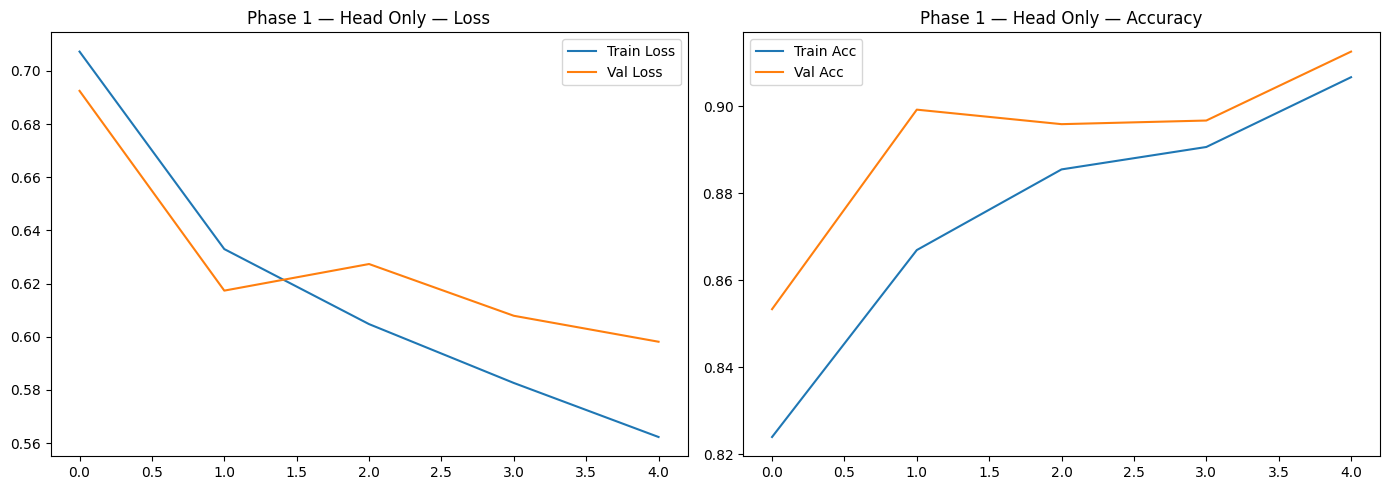

In [28]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FROZEN)

history_phase1 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=" * 55)
print("  PHASE 1 — Training classifier head (backbone frozen)")
print("=" * 55)

for epoch in range(1, EPOCHS_FROZEN + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history_phase1['train_loss'].append(tr_loss)
    history_phase1['val_loss'].append(vl_loss)
    history_phase1['train_acc'].append(tr_acc)
    history_phase1['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS_FROZEN} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

plot_history(history_phase1, "Phase 1 — Head Only")

  PHASE 2 — Fine-tuning full ResNet50
  ✅ Best model saved  (val_acc=0.9867)
Epoch 01/15 | Train Loss: 0.3941  Acc: 0.9893 | Val Loss: 0.3884  Acc: 0.9867
  ✅ Best model saved  (val_acc=0.9908)
Epoch 02/15 | Train Loss: 0.3867  Acc: 0.9919 | Val Loss: 0.3798  Acc: 0.9908

🎯 Early stopping triggered — Val Accuracy reached 99.08% at epoch 2


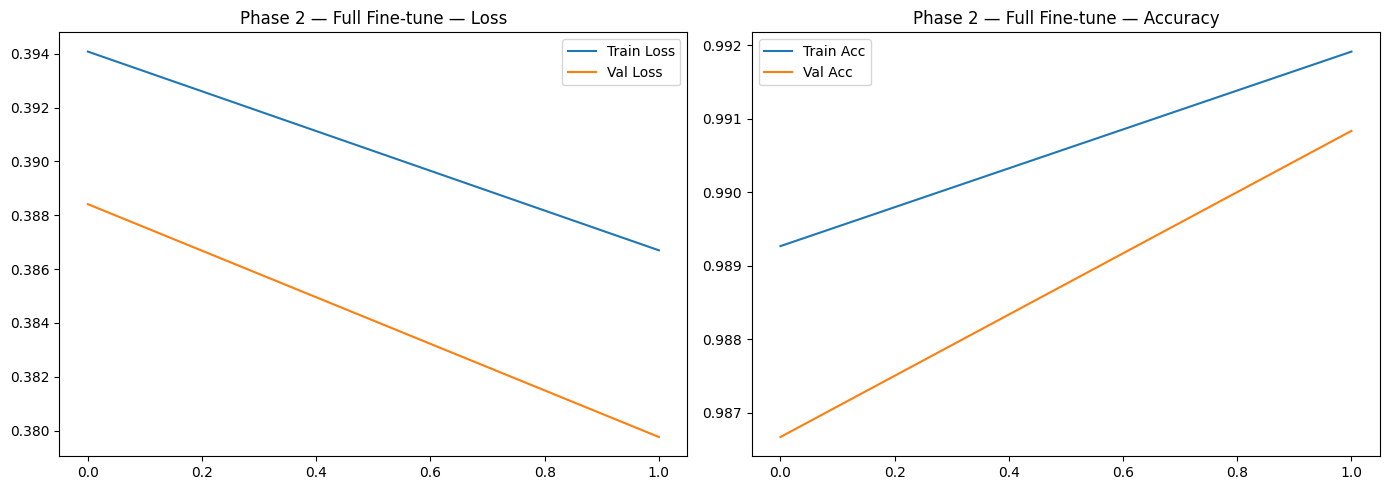


Best Validation Accuracy: 0.9908


In [33]:
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=LR_FINETUNE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE, eta_min=1e-6)

best_val_acc = 0.0
history_phase2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=" * 55)
print("  PHASE 2 — Fine-tuning full ResNet50")
print("=" * 55)

for epoch in range(1, EPOCHS_FINETUNE + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history_phase2['train_loss'].append(tr_loss)
    history_phase2['val_loss'].append(vl_loss)
    history_phase2['train_acc'].append(tr_acc)
    history_phase2['val_acc'].append(vl_acc)

    # Save best checkpoint
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "best_resnet50_brain.pth")
        print(f"  ✅ Best model saved  (val_acc={vl_acc:.4f})")

    print(f"Epoch {epoch:02d}/{EPOCHS_FINETUNE} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

    # ── Early stop if val accuracy hits 99% ─────────────
    if vl_acc >= 0.99:
        print(f"\n🎯 Early stopping triggered — Val Accuracy reached {vl_acc*100:.2f}% at epoch {epoch}")
        break

plot_history(history_phase2, "Phase 2 — Full Fine-tune")
print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


  TEST SET — Classification Report
              precision    recall  f1-score   support

      glioma       0.99      0.86      0.92       400
  meningioma       0.93      0.99      0.96       400
   pituitary       0.93      0.99      0.96       400
     notumor       0.99      0.99      0.99       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



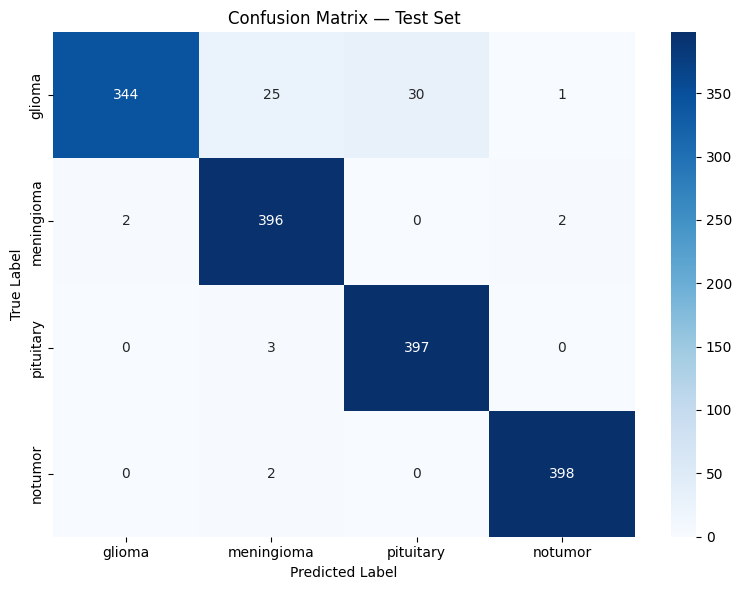


Final Test Accuracy: 0.9594 (95.94%)


In [30]:
# Load best checkpoint
model.load_state_dict(torch.load("best_resnet50_brain.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# ── Classification Report ────────────────────────────────
print("\n" + "=" * 55)
print("  TEST SET — Classification Report")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# ── Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

test_acc = np.array(all_preds) == np.array(all_labels)
print(f"\nFinal Test Accuracy: {test_acc.mean():.4f} ({test_acc.mean()*100:.2f}%)")

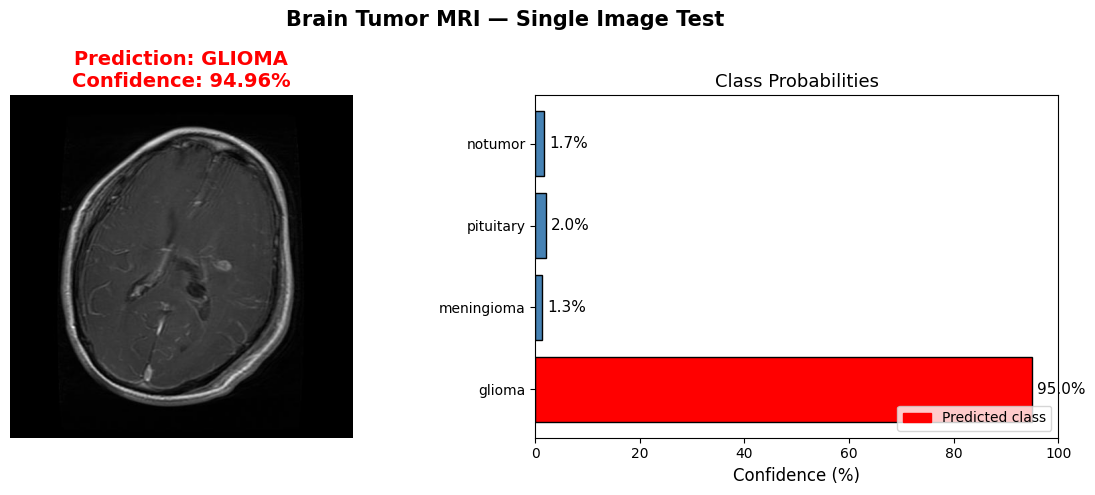


  Image     : /content/Te-gl_10.jpg
  Prediction: GLIOMA
  Confidence: 94.96%


In [32]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import transforms

# ── CONFIG ──────────────────────────────────────────────
# Change this to any image path you want to test
IMAGE_PATH = "/content/Te-gl_10.jpg"   # <-- change this

CLASSES = ["glioma", "meningioma", "pituitary", "notumor"]
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Transform ────────────────────────────────────────────
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Load Model ───────────────────────────────────────────
model.load_state_dict(torch.load("best_resnet50_brain.pth", map_location=DEVICE))
model.eval()

# ── Predict ──────────────────────────────────────────────
img = Image.open(IMAGE_PATH).convert("RGB")
tensor = infer_transform(img).unsqueeze(0).to(DEVICE)   # add batch dim

with torch.no_grad():
    outputs = model(tensor)
    probs   = torch.softmax(outputs, dim=1).squeeze()    # confidence scores
    pred_idx = probs.argmax().item()

pred_label      = CLASSES[pred_idx]
pred_confidence = probs[pred_idx].item() * 100

# ── Display ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left — MRI image with prediction label
ax1.imshow(img)
ax1.axis("off")
color = "red" if pred_label != "notumor" else "green"
ax1.set_title(f"Prediction: {pred_label.upper()}\nConfidence: {pred_confidence:.2f}%",
              fontsize=14, fontweight="bold", color=color)

# Right — Confidence bar chart for all classes
colors = ["red" if c == pred_label else "steelblue" for c in CLASSES]
bars = ax2.barh(CLASSES, [probs[i].item() * 100 for i in range(4)],
                color=colors, edgecolor="black")
ax2.set_xlim(0, 100)
ax2.set_xlabel("Confidence (%)", fontsize=12)
ax2.set_title("Class Probabilities", fontsize=13)
for bar, prob in zip(bars, probs):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             f"{prob.item()*100:.1f}%", va="center", fontsize=11)

patch = mpatches.Patch(color="red", label="Predicted class")
ax2.legend(handles=[patch], loc="lower right")

plt.suptitle("Brain Tumor MRI — Single Image Test", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'='*45}")
print(f"  Image     : {IMAGE_PATH}")
print(f"  Prediction: {pred_label.upper()}")
print(f"  Confidence: {pred_confidence:.2f}%")
print(f"{'='*45}")